# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC; width: 100%;"><b>🏃 [Competiton : Predict Calorie Expenditure](https://www.kaggle.com/competitions/playground-series-s5e5/)</b></div>

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC; width: 100%;"><b></b>Introduction</div>

Throughout this notebook we dissect the 750 k × 9 training set and the 250 k × 8 test set from every angle.

| Section | What we do | Why it matters |
|---------|------------|----------------|
| 1‑3     | Load libraries & glimpse raw tables | Sanity check shapes and dtypes |
| 4       | Missing‑value audit | Confirm data hygiene (spoiler: it’s perfect) |
| 5       | Target (`Calories`) deep dive | Pick the right loss transformation |
| 6‑7     | Univariate numeric & categorical plots | Detect skew, outliers, class balance |
| 8‑10    | Correlations, bivariate scatter & interactions | Reveal linear / non‑linear drivers |
| 11‑12   | Outlier count & multicollinearity (VIF) | Decide on cleaning and feature pruning |
| 13      | PCA preview | Gauge underlying dimensionality |
| 14      | Train‑vs‑test comparability | Verify no covariate shift |

At the end we summarise the **seven key insights** and sketch a data‑driven modelling roadmap.

Join the discussion [here](https://www.kaggle.com/competitions/playground-series-s5e5/)

---

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Executive Summary</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Summary</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </div>

# <b><span style="color: #FFFFFF; background-color: #7851A9; padding: 20px; font-size: 18px; border-left: 8px solid #C9A0DC">Importing Libraries</span></b>

In [1]:
# Table Manipulation, CalculatinTg
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', 100) # increase the maximum number of columns

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ignore all warnings
import warnings
warnings.simplefilter("ignore")

# <b><span style="color: #FFFFFF; background-color: #7851A9; padding: 20px; font-size: 18px; border-left: 8px solid #C9A0DC">Importing Datasets</span>

In [2]:
df_train = pd.read_csv('/kaggle/input/playground-series-s5e5/train.csv')
df_test = pd.read_csv('/kaggle/input/playground-series-s5e5/test.csv')

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Column list:</strong> 
  </h5>
  <ul>
    <li><strong>id</strong> : <em>Identification number.</em>
    <li><strong>Age</strong> : <em>The biological sex of the individual.</em>
    <li><strong>Height</strong> : <em>The height of the individual.</em>
    <li><strong>Weight</strong> : <em>The weight of the individual.</em>
    <li><strong>Duration</strong> : <em>The length of the physical activity being recorded.</em>
    <li><strong>Heart_Rate</strong> : <em>The number of times the heart beats per minute during the activity.</em>
    <li><strong>Body_Temp</strong> : <em>The body temperature of the individual.</em>
    <li><strong>Calories</strong> : <em>The number of calories burned by the individual during the recorded physical activity.</em>
  </ul>
</div>

In [3]:
df_train

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...,...
749995,749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0


In [4]:
df_test

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5
...,...,...,...,...,...,...,...,...
249995,999995,female,56,159.0,62.0,6.0,85.0,39.4
249996,999996,male,32,202.0,101.0,3.0,84.0,38.4
249997,999997,female,31,164.0,64.0,14.0,98.0,40.1
249998,999998,female,62,158.0,61.0,25.0,106.0,40.7


# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>📊EDA</b>

## <b><span style="color: #FFFFFF; background-color: #7851A9; padding: 20px; font-size: 18px; border-left: 8px solid #C9A0DC">Whole</span>

## <b><span style="color: #FFFFFF; background-color: #7851A9; padding: 20px; font-size: 18px; border-left: 8px solid #C9A0DC">Data Inspection</span>

In [5]:
# Check if each column has a unique value of 0 and 1, and assign 1 or 0
def check_if_binary(column):
    unique_values = column.unique()
    if len(unique_values) == 2 and set(unique_values) == {0, 1}:
        return 1
    else:
        return 0

In [6]:
def check_if_outliers(df):

    outliers_rate_dict = {}

    for column_name in df.columns:
        column = df[column_name]

        # Skip if not a numeric column
        if not pd.api.types.is_numeric_dtype(column):
            print(f"'{column_name}' is skipped because it is not a numeric type.")
            continue

        # Calculate the mean and standard deviation of the data
        mean = column.mean()
        std = column.std()

        # Set outlier threshold
        threshold = 2  # Adjust this value to change the outlier criteria

        # Set conditions for detecting outliers
        lower_bound = mean - threshold * std
        upper_bound = mean + threshold * std

        # Detect outliers
        outliers = (column < lower_bound) | (column > upper_bound)

        # Calculate the percentage of outliers
        outliers_rate = outliers.sum() / len(column)

        # Save results to dictionary
        outliers_rate_dict[column_name] = outliers_rate

    return outliers_rate_dict

In [7]:
def data_inspection(df):
    """A function that generates data inspection information for a data frame"""

    # process_one:Create a DataFrame with basic statistics
    data_inspection = pd.DataFrame({
        'column_name'         : df.columns,
        'data_type'           : df.dtypes,
        'cnt_rows'            : len(df),
        'cnt_unique_rows'     : df.nunique(),
        'cnt_duplicated_rows' : len(df) - df.nunique(),
        'cnt_non_null_rows'   : df.count().values,
        'cnt_null_rows'       : df.isnull().sum(),
        'rate_null_rows'      : (df.isnull().sum() / len(df)),
    })

    # process_two:Calculate descriptive statistics, modes, and percentages of modes for numerical data:
    
    # The below code is no longer needed as 'custom_description' provides the stats
    # description = df.describe(include=np.number).T.reset_index().rename(columns={'index': 'column_name'})
    # median = df.median(numeric_only=True).reset_index().rename(columns={'index': 'column_name', 0: 'median'})

    # Calculate the most frequent value for each column
    mode_values = {}
    for column in df.columns:
        try:
            mode_values[column] = df[column].mode().iloc[0]
        except IndexError:
            mode_values[column] = None  # Handle cases with no mode

    # Calculate the percentage of most frequent values
    mode_rates = {}
    for column in df.columns:
        if column in mode_values and mode_values[column] is not None:
            mode_value = mode_values[column]
            mode_rate = (df[column] == mode_value).sum() / len(df)
            mode_rates[column] = mode_rate
        else:
            mode_rates[column] = None

    # Convert the most common value and its percentage into a data frame
    df_mode = pd.DataFrame(list(mode_values.items()), columns=['column_name', 'mode'])
    df_mode['rate mode'] = df_mode['column_name'].map(mode_rates)

    # Custom statistics calculation without using df.describe for basic stats
    def calculate_custom_stats(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        return pd.Series({
            'count': series.count(),
            'mean': series.mean(),
            'std': series.std(),
            # 'q1-1.5*QTR': q1 - 1.5 * iqr,
            '0%': series.quantile(0),
            '25%': q1,
            '50%': series.median(),
            '75%': q3,
            '100%': series.quantile(1),
            'lower_bound': series.mean() - 2 * series.std(),
            'upper_bound': series.mean() + 2 * series.std()
            # 'q3+1.5*QTR': q3 + 1.5 * iqr
        })

    df_numeric = df.select_dtypes(include=np.number)
    custom_description = df_numeric.apply(calculate_custom_stats).T.reset_index(names='column_name')

    # process_three:Combining DataFrames and adding outlier rates, skewness, and kurtosis:
    data_inspection = pd.merge(data_inspection, custom_description, how='left', on='column_name')
    data_inspection = pd.merge(data_inspection, df_mode, how='left', on='column_name')

    # # The 'description' merge is no longer needed as 'custom_description' provides the stats
    # data_inspection = pd.merge(data_inspection, description, how='left', on='column_name')

    outliers_rate = check_if_outliers(df)
    outliers_rate = pd.DataFrame(list(outliers_rate.items()), columns=['column_name', 'outliers_rate']).reset_index(drop=True)
    data_inspection = pd.merge(data_inspection, outliers_rate, how='left', on='column_name')

    # skewness and kurtosis
    skew = df.select_dtypes(include=np.number).skew().reset_index().rename(columns={'index': 'column_name', 0: 'skewness'})
    kurt = df.select_dtypes(include=np.number).kurt().reset_index().rename(columns={'index': 'column_name', 0: 'kurtosis'})

    data_inspection = pd.merge(data_inspection, skew, how='left', on='column_name')
    data_inspection = pd.merge(data_inspection, kurt, how='left', on='column_name')

    # Calculating correlation coefficients (numeric columns only)
    df_numeric = df.select_dtypes(include=np.number)
    if not df_numeric.empty and df_numeric.shape[1] > 1:
        try:
            correlation_matrix = df_numeric.corr(numeric_only=True)

            # Assuming the last column is the target variable for correlation
            target_column = df_numeric.columns[-1]
            if target_column in correlation_matrix.index:
                target_corr = pd.DataFrame({'column_name': correlation_matrix.index, 'target correlation': correlation_matrix[target_column]})
                data_inspection = pd.merge(data_inspection, target_corr, how='left', on='column_name')
            else:
                data_inspection['target correlation'] = np.nan
        except Exception as e:
            print(f"Error calculating correlation: {e}")
            data_inspection['target correlation'] = np.nan
    else:
        data_inspection['target correlation'] = np.nan

    # process_four:Adding more column information and example data
    data_inspection_else = pd.DataFrame({
        'column_name': df.columns,
        'flag_or_not': df.apply(check_if_binary),
        'columns_details': None,
        'remarks': None,
        'trigger': None,
        'dataset_name': None,
        'existence_of_table_definition': None,
        'data_exmaple': df.head(1).T.iloc[:, 0].astype(str).replace('\n', '<br>')
    })

    data_inspection = pd.merge(data_inspection, data_inspection_else, how='left', on='column_name')

    # visualization `data_inspection`
    # blue → green → yellow
    styled_columns = data_inspection.select_dtypes(include=np.number).columns
    if not styled_columns.empty:
        data_inspection_styled = data_inspection.style.background_gradient(cmap='viridis', subset=pd.IndexSlice[:, styled_columns])
    else:
        data_inspection_styled = data_inspection

    return data_inspection_styled

### <b><span style="color: #FFFFFF; background-color: #7851A9; padding: 20px; font-size: 18px; border-left: 8px solid #C9A0DC">df_train</span></b>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>
  </div>

In [8]:
df_train_tmp = df_train.drop('id', axis=1)
data_inspection_styled = data_inspection(df_train_tmp)
display(data_inspection_styled)
# data_inspection.to_csv('data_inspection.csv', index = 'false')

'Sex' is skipped because it is not a numeric type.


,column_name,data_type,cnt_rows,cnt_unique_rows,cnt_duplicated_rows,cnt_non_null_rows,cnt_null_rows,rate_null_rows,count,mean,std,0%,25%,50%,75%,100%,lower_bound,upper_bound,mode,rate mode,outliers_rate,skewness,kurtosis,target correlation,flag_or_not,columns_details,remarks,trigger,dataset_name,existence_of_table_definition,data_exmaple
0,Sex,object,750000,2,749998,750000,0,0.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,female,0.500961,nan,nan,nan,nan,0,None,None,None,None,None,male
1,Age,int64,750000,60,749940,750000,0,0.000000,750000.000000,41.420404,15.175049,20.000000,28.000000,40.000000,52.000000,79.000000,11.070306,71.770502,21,0.048520,0.035976,0.436397,-0.746338,0.145683,0,None,None,None,None,None,36
2,Height,float64,750000,86,749914,750000,0,0.000000,750000.000000,174.697685,12.824496,126.000000,164.000000,174.000000,185.000000,222.000000,149.048694,200.346677,161.000000,0.035387,0.022101,0.051777,-0.839800,-0.004026,0,None,None,None,None,None,189.0
3,Weight,float64,750000,91,749909,750000,0,0.000000,750000.000000,75.145668,13.982704,36.000000,63.000000,74.000000,87.000000,132.000000,47.180261,103.111075,61.000000,0.037292,0.009600,0.211194,-0.996077,0.015863,0,None,None,None,None,None,82.0
4,Duration,float64,750000,30,749970,750000,0,0.000000,750000.000000,15.421015,8.354095,1.000000,8.000000,15.000000,23.000000,30.000000,-1.287176,32.129206,9.000000,0.038533,0.000000,0.026259,-1.195390,0.959908,0,None,None,None,None,None,26.0
5,Heart_Rate,float64,750000,63,749937,750000,0,0.000000,750000.000000,95.483995,9.449845,67.000000,88.000000,95.000000,103.000000,128.000000,76.584304,114.383685,91.000000,0.045844,0.026051,-0.005668,-0.676563,0.908748,0,None,None,None,None,None,101.0
6,Body_Temp,float64,750000,75,749925,750000,0,0.000000,750000.000000,40.036253,0.779875,37.100000,39.600000,40.300000,40.700000,41.500000,38.476504,41.596002,40.700000,0.089667,0.049905,-1.022361,0.519624,0.828671,0,None,None,None,None,None,41.0
7,Calories,float64,750000,277,749723,750000,0,0.000000,750000.000000,88.282781,62.395349,1.000000,34.000000,77.000000,136.000000,314.000000,-36.507917,213.073479,7.000000,0.011133,0.029272,0.539196,-0.689513,1.000000,0,None,None,None,None,None,150.0


### <b><span style="color: #FFFFFF; background-color: #7851A9; padding: 20px; font-size: 18px; border-left: 8px solid #C9A0DC">df_test</span></b>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>
  </div>

In [9]:
df_test_tmp = df_test.drop('id', axis=1)
data_inspection_styled = data_inspection(df_test_tmp)
display(data_inspection_styled)
# data_inspection.to_csv('data_inspection.csv', index = 'false')

'Sex' is skipped because it is not a numeric type.


,column_name,data_type,cnt_rows,cnt_unique_rows,cnt_duplicated_rows,cnt_non_null_rows,cnt_null_rows,rate_null_rows,count,mean,std,0%,25%,50%,75%,100%,lower_bound,upper_bound,mode,rate mode,outliers_rate,skewness,kurtosis,target correlation,flag_or_not,columns_details,remarks,trigger,dataset_name,existence_of_table_definition,data_exmaple
0,Sex,object,250000,2,249998,250000,0,0.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,female,0.501124,nan,nan,nan,nan,0,None,None,None,None,None,male
1,Age,int64,250000,60,249940,250000,0,0.000000,250000.000000,41.452464,15.177769,20.000000,28.000000,40.000000,52.000000,79.000000,11.096926,71.808002,21,0.048736,0.035920,0.434611,-0.749070,0.031114,0,None,None,None,None,None,45
2,Height,float64,250000,85,249915,250000,0,0.000000,250000.000000,174.725624,12.822039,127.000000,164.000000,174.000000,185.000000,219.000000,149.081546,200.369702,187.000000,0.035128,0.021656,0.043409,-0.843128,-0.033645,0,None,None,None,None,None,177.0
3,Weight,float64,250000,84,249916,250000,0,0.000000,250000.000000,75.147712,13.979513,39.000000,63.000000,74.000000,87.000000,126.000000,47.188687,103.106737,61.000000,0.037244,0.009288,0.207449,-1.002317,-0.023704,0,None,None,None,None,None,81.0
4,Duration,float64,250000,30,249970,250000,0,0.000000,250000.000000,15.415428,8.349133,1.000000,8.000000,15.000000,23.000000,30.000000,-1.282838,32.113694,9.000000,0.038488,0.000000,0.030302,-1.193598,0.902594,0,None,None,None,None,None,7.0
5,Heart_Rate,float64,250000,61,249939,250000,0,0.000000,250000.000000,95.479084,9.450161,67.000000,88.000000,95.000000,103.000000,128.000000,76.578763,114.379405,91.000000,0.046244,0.026084,-0.005194,-0.675792,0.794969,0,None,None,None,None,None,87.0
6,Body_Temp,float64,250000,51,249949,250000,0,0.000000,250000.000000,40.036093,0.778448,37.100000,39.600000,40.300000,40.600000,41.500000,38.479197,41.592988,40.700000,0.088524,0.049848,-1.021889,0.523997,1.000000,0,None,None,None,None,None,39.8


# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>Missing Values Analysis</b></div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>
  </div>

In [10]:
def create_missing_value_plots(df: pd.DataFrame):
    """
    It generates four types of plots (Matrix, Bar, Heatmap, Dendrogram) to visualize missing values ​​in a data frame.

    Args:
        df (pd.DataFrame): The DataFrame to perform missing value analysis on.
    """
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))

    # Missing Value Matrix
    msno.matrix(df, sparkline=True, ax=axes[0, 0], color=(0.2, 0.2, 0.2))
    axes[0, 0].set_title("Missing Value Matrix")

    # Missing Value Bar Plot
    msno.bar(df, ax=axes[0, 1], color='skyblue')
    axes[0, 1].set_title("Missing Value Bar Plot")

    # Missing Value Correlation Heatmap
    msno.heatmap(df, ax=axes[1, 0], cmap='viridis')
    axes[1, 0].set_title("Missing Value Correlation Heatmap")

    # Missing Value Dendrogram
    msno.dendrogram(df, ax=axes[1, 1])
    axes[1, 1].set_title("Missing Value Dendrogram")

    # Adjusting the layout
    plt.tight_layout()
    plt.show()

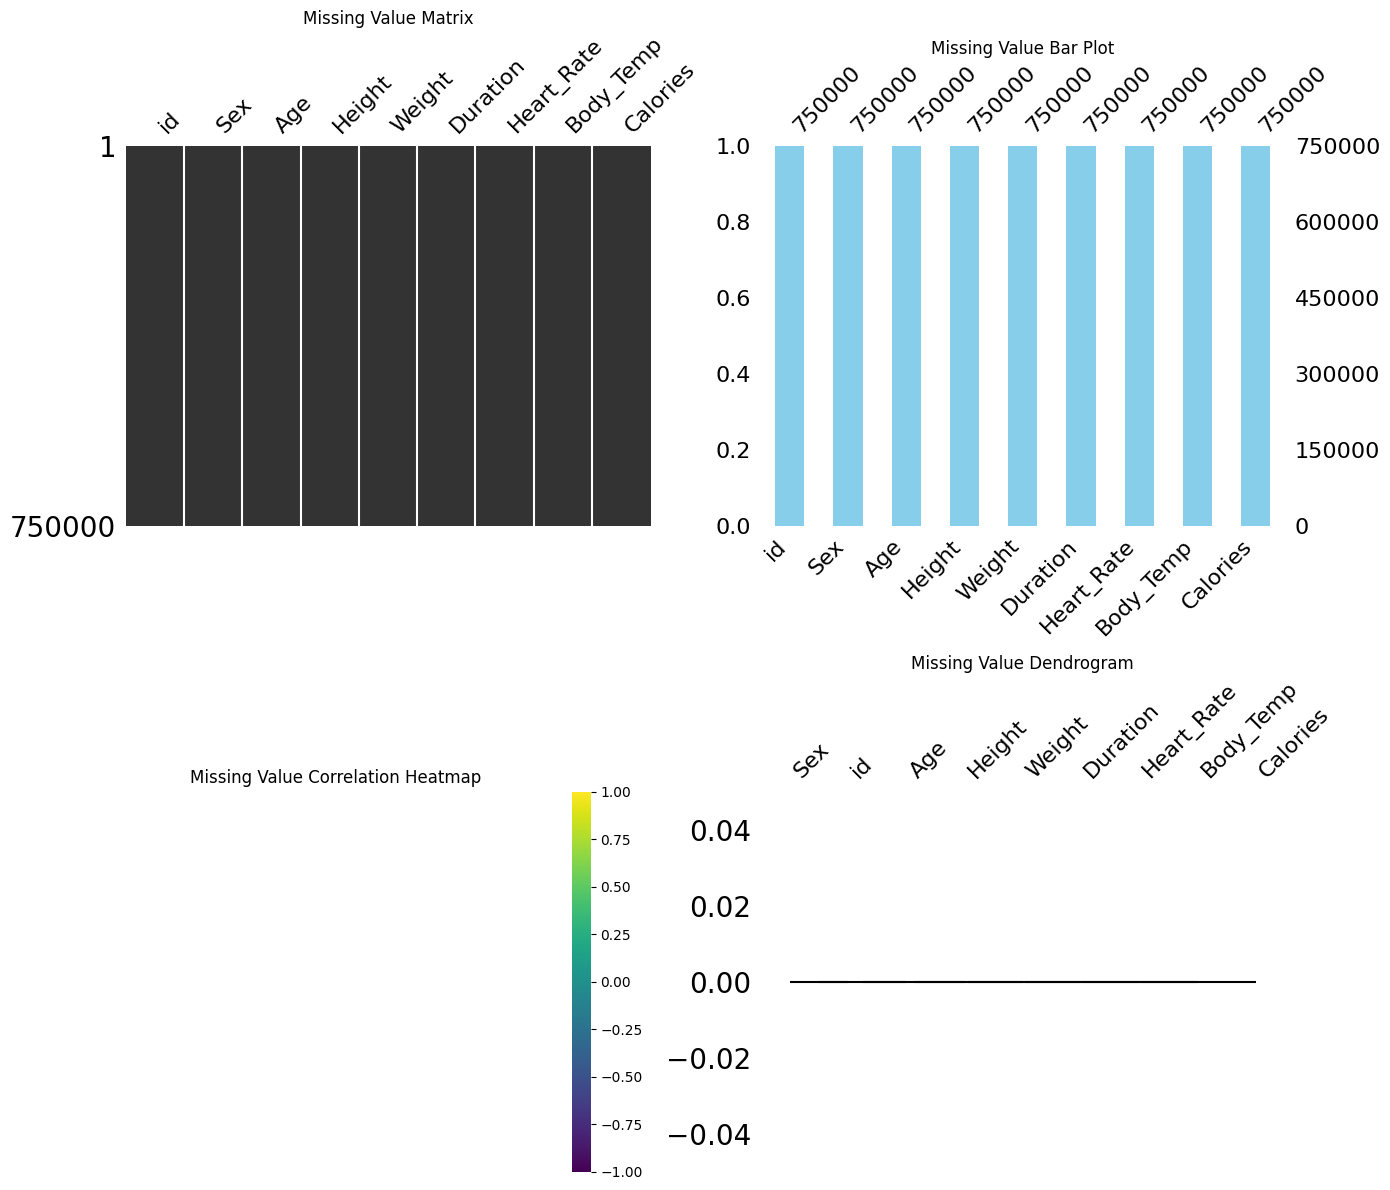

In [11]:
# df_train
create_missing_value_plots(df_train)

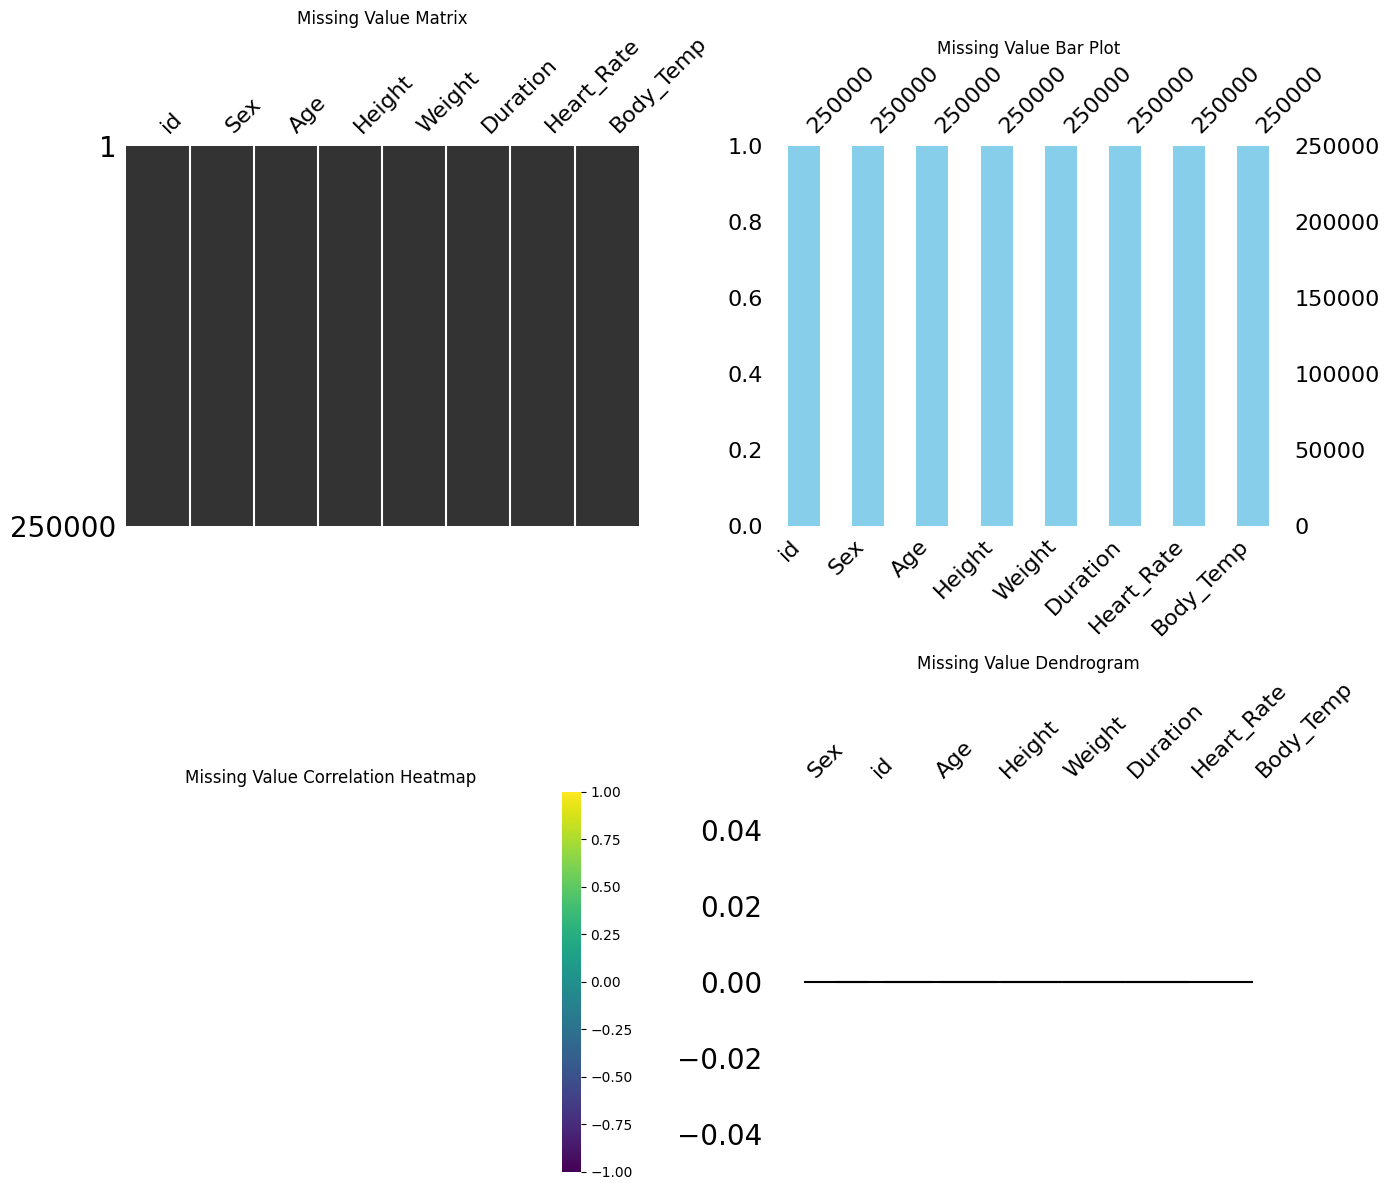

In [12]:
# df_test
create_missing_value_plots(df_test)

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>Univariate</b></div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>
  </div>

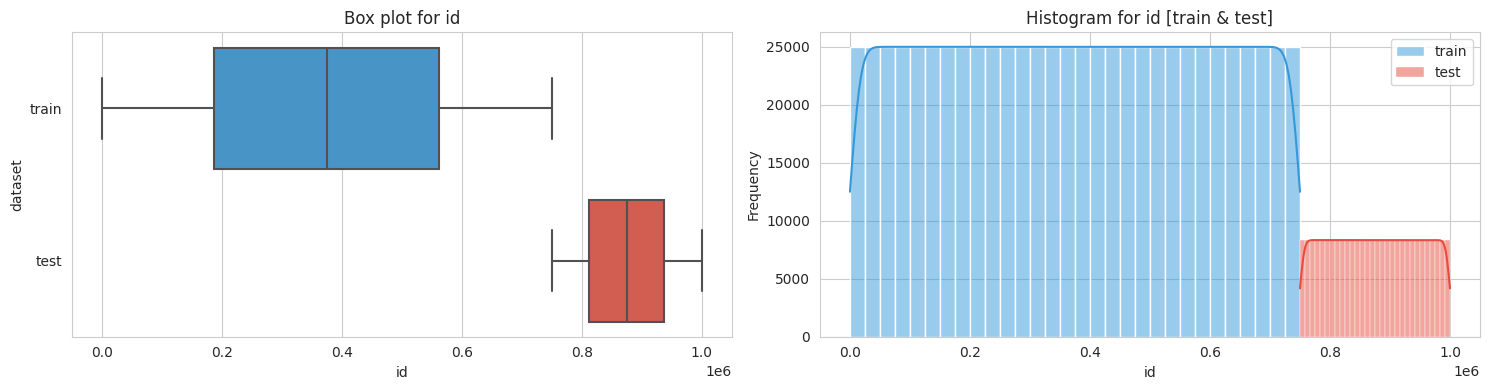

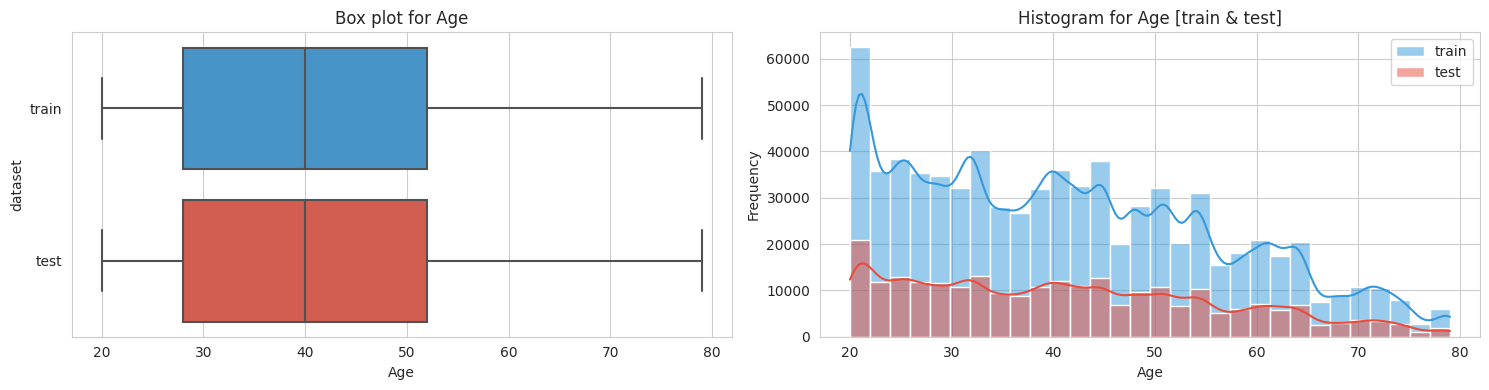

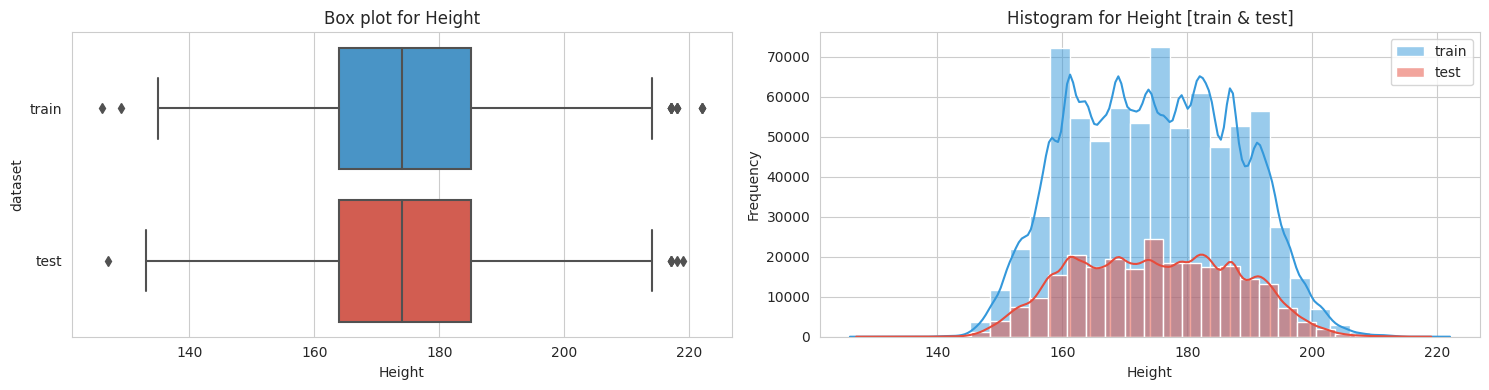

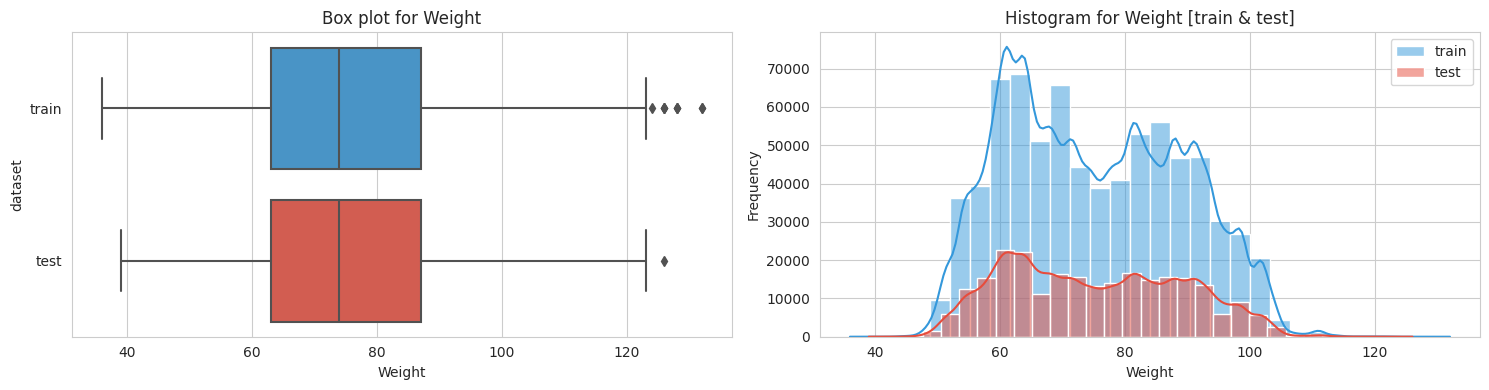

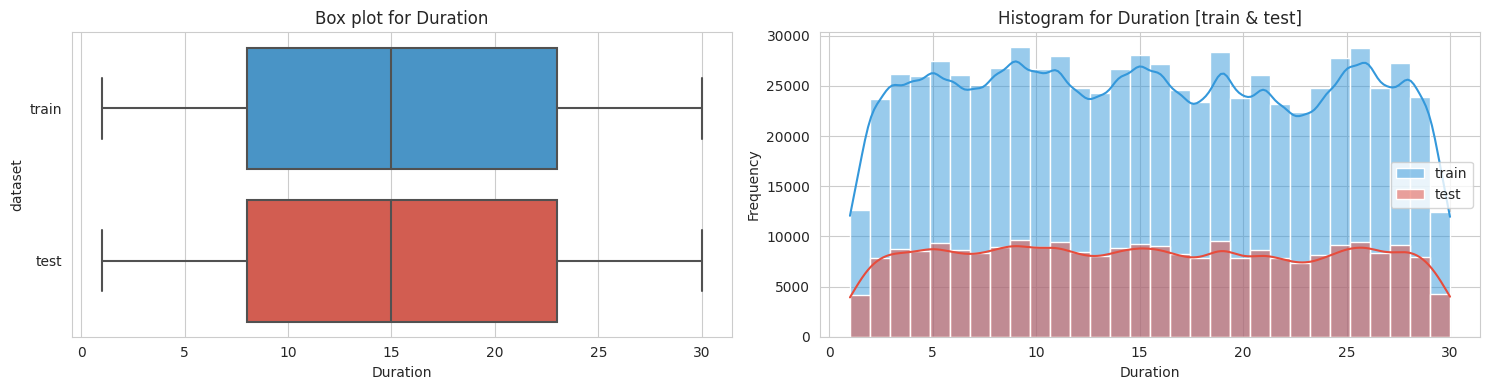

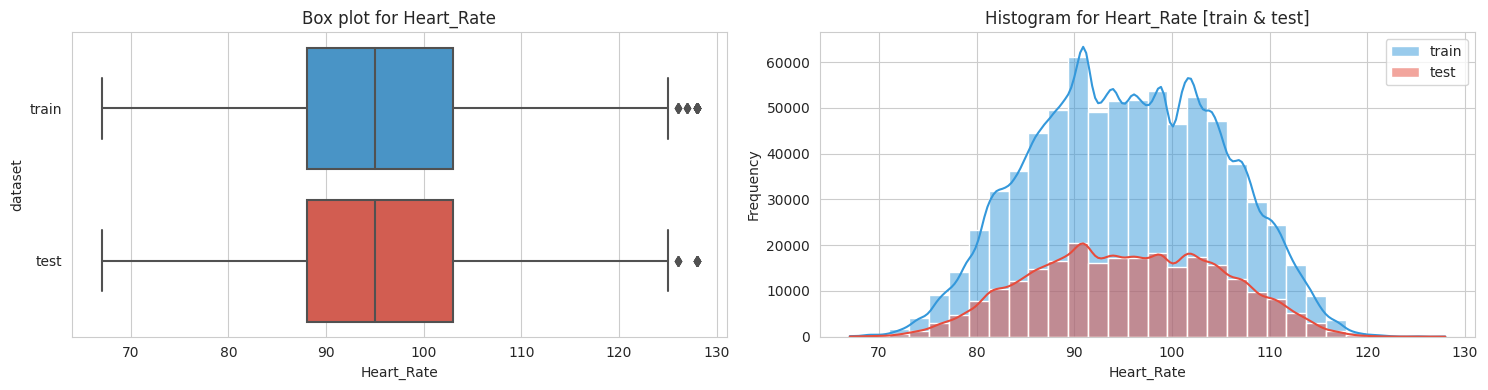

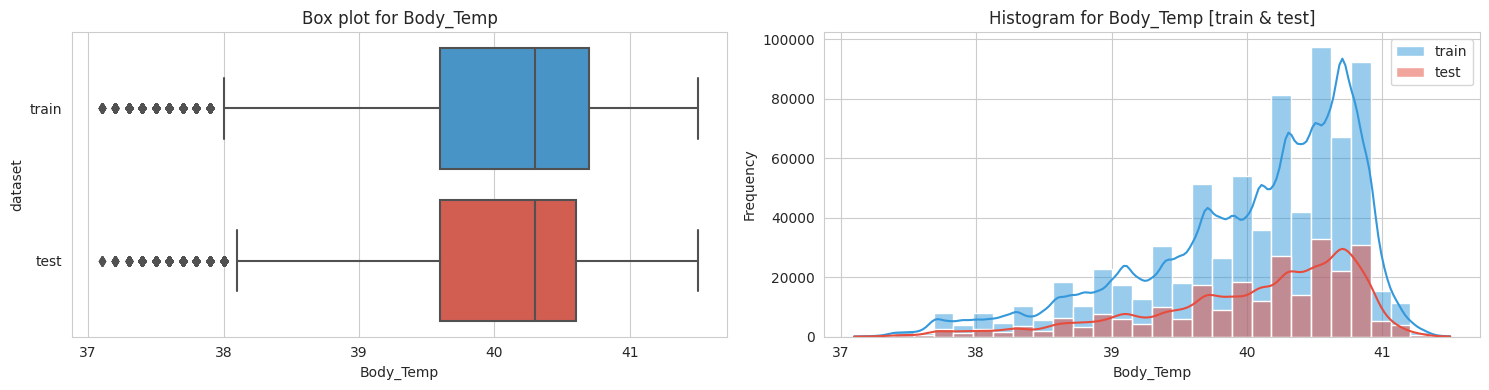

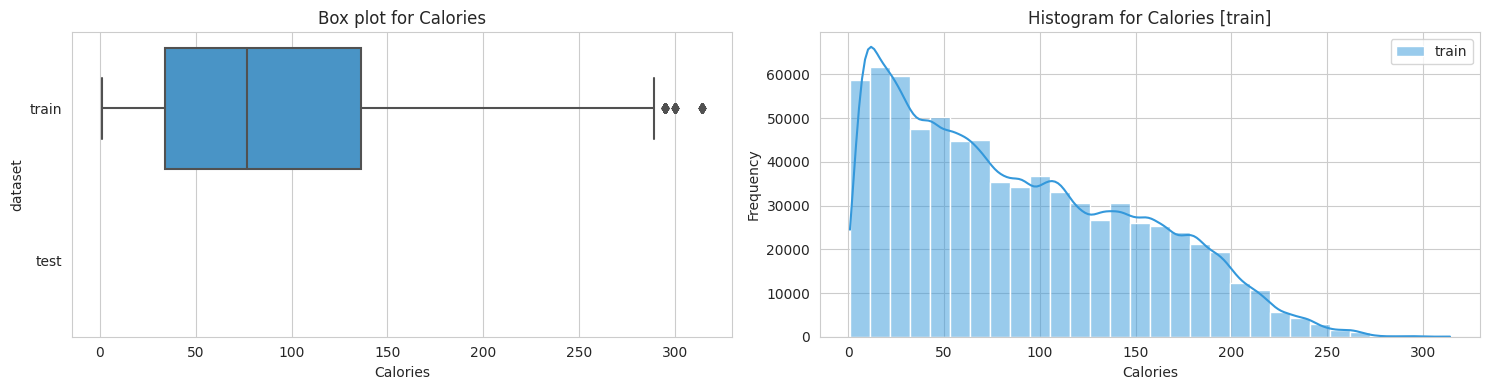

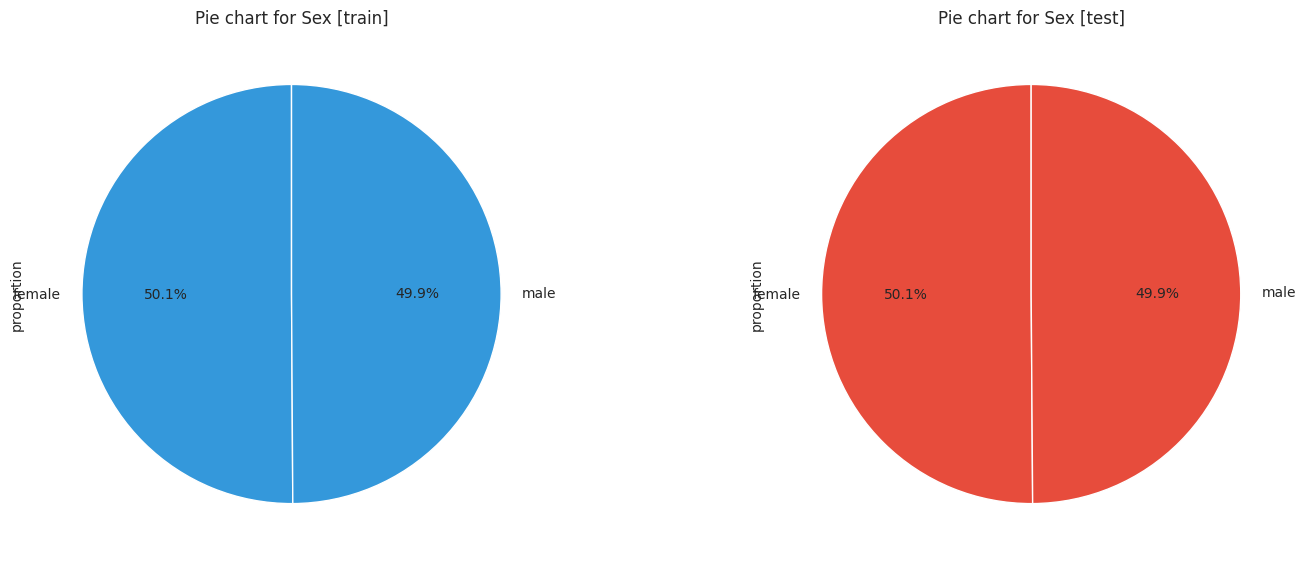

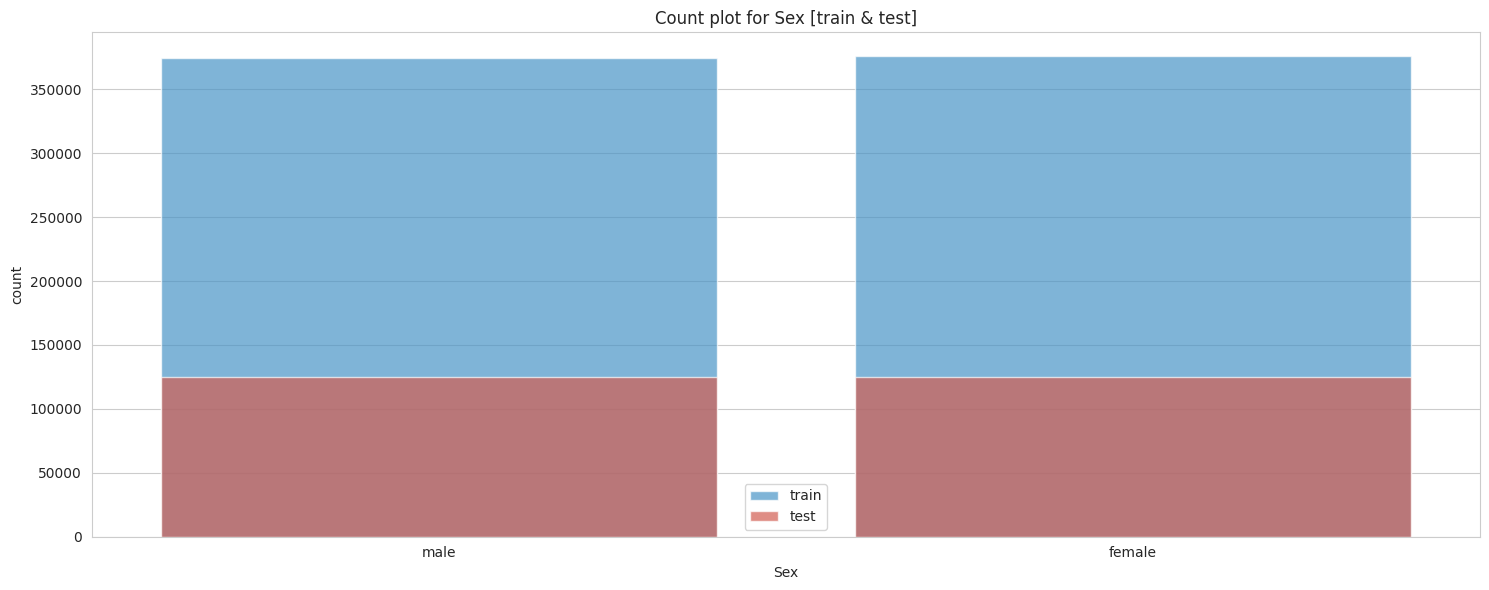

<Figure size 640x480 with 0 Axes>

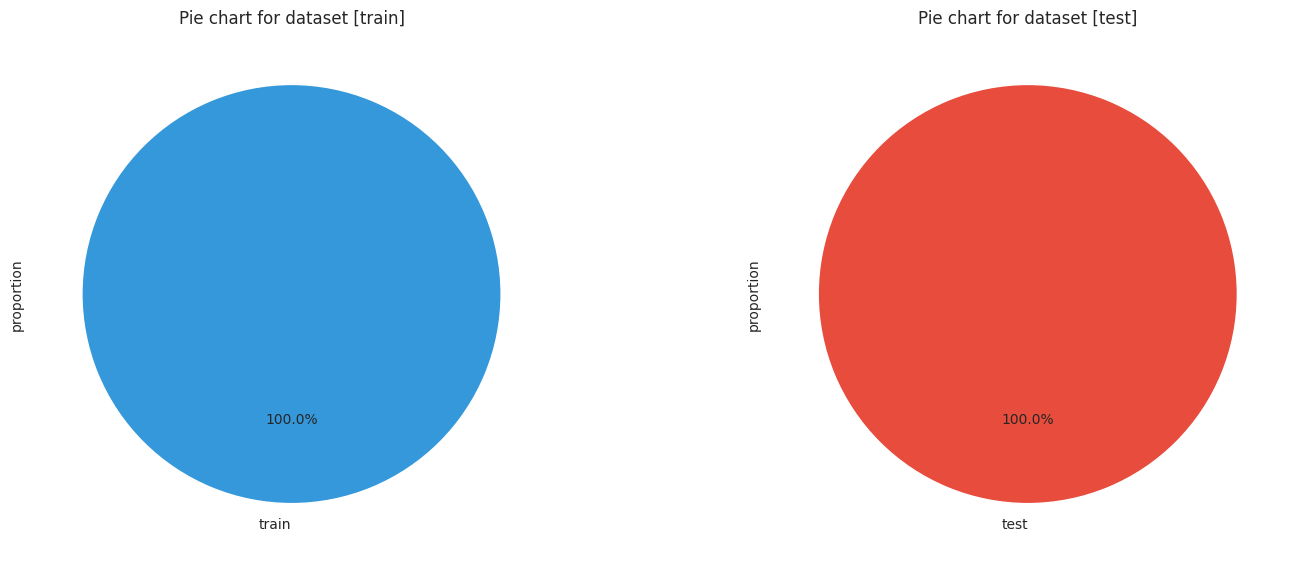

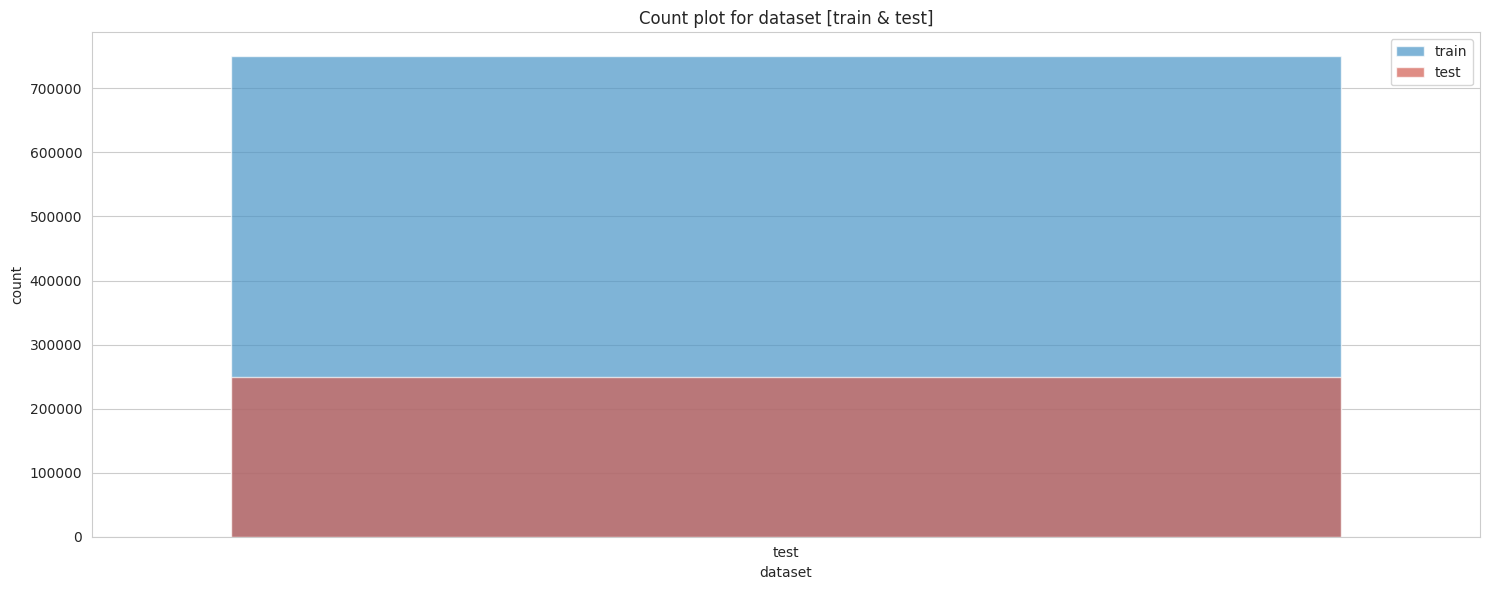

<Figure size 640x480 with 0 Axes>

In [13]:
# custom palette of colors
custom_palette = ['#3498db', '#e74c3c','#2ecc71']

# Add 'Dataset' column to distinguish between train and test data
df_train['dataset'] = 'train'
df_test['dataset'] = 'test'

# Create a list of variables (both numerical and categorical data)
numerical_variables = df_train.select_dtypes(include=['number']).columns
categorical_variables = df_train.select_dtypes(include=['object']).columns

# A function to create plots for each variable
def create_variable_plots(variable, data_type='numerical'):

    sns.set_style('whitegrid')

    # For numeric data
    if data_type == 'numerical':
        fig, axes = plt.subplots(1, 2, figsize=(15, 4))

        # Box plot
        plt.subplot(1, 2, 1)
        sns.boxplot(data=pd.concat([df_train, df_test]), x=variable, y="dataset", palette=custom_palette)
        plt.xlabel(variable)
        plt.title(f"Box plot for {variable}")

        # histgram
        plt.subplot(1, 2, 2)
        sns.histplot(data=df_train, x=variable, color=custom_palette[0], kde=True, bins=30, label="train")
        if variable in df_test.columns:
            sns.histplot(data=df_test, x=variable, color=custom_palette[1], kde=True, bins=30, label="test")

        plt.xlabel(variable)
        plt.ylabel("Frequency")
        plt.title(f"Histogram for {variable} [train & test]" if variable in df_test.columns else f"Histogram for {variable} [train]")
        plt.legend()

    # For categorical data
    elif data_type == 'categorical':
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # pie chart for train data
        plt.subplot(1, 2, 1)
        train_counts = df_train[variable].value_counts(normalize=True)
        train_counts.plot(kind='pie', autopct='%1.1f%%', colors=[custom_palette[0]] * len(train_counts), startangle=90, ax=plt.gca())
        plt.title(f"Pie chart for {variable} [train]")
        plt.tight_layout()

        # pie chart for test data
        plt.subplot(1, 2, 2)
        if variable in df_test.columns:
            test_counts = df_test[variable].value_counts(normalize=True)
            test_counts.plot(kind='pie', autopct='%1.1f%%', colors=[custom_palette[1]] * len(test_counts), startangle=90, ax=plt.gca())
            plt.title(f"Pie chart for {variable} [test]")
        else:
            plt.gca().axis('off') # Empty plot if no columns in test data

        # countplot
        fig_countplot, ax_countplot = plt.subplots(figsize=(15, 6))
        sns.countplot(data=df_train, x=variable, color=custom_palette[0], alpha=0.7, label="train", ax=ax_countplot)
        if variable in df_test.columns:
            sns.countplot(data=df_test, x=variable, color=custom_palette[1], alpha=0.7, label="test", ax=ax_countplot)
        ax_countplot.set_title(f"Count plot for {variable} [train & test]")
        ax_countplot.legend()
        plt.tight_layout()
        plt.show()

    plt.tight_layout()
    plt.show()

# Create plots for numerical data
for variable in numerical_variables:
    create_variable_plots(variable, data_type='numerical')

# Create plots for categorical data
for variable in categorical_variables:
    create_variable_plots(variable, data_type='categorical')

# remove unnecessary columns
del df_train['dataset']
del df_test['dataset']

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>Vivariate</b></div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>
  </div>

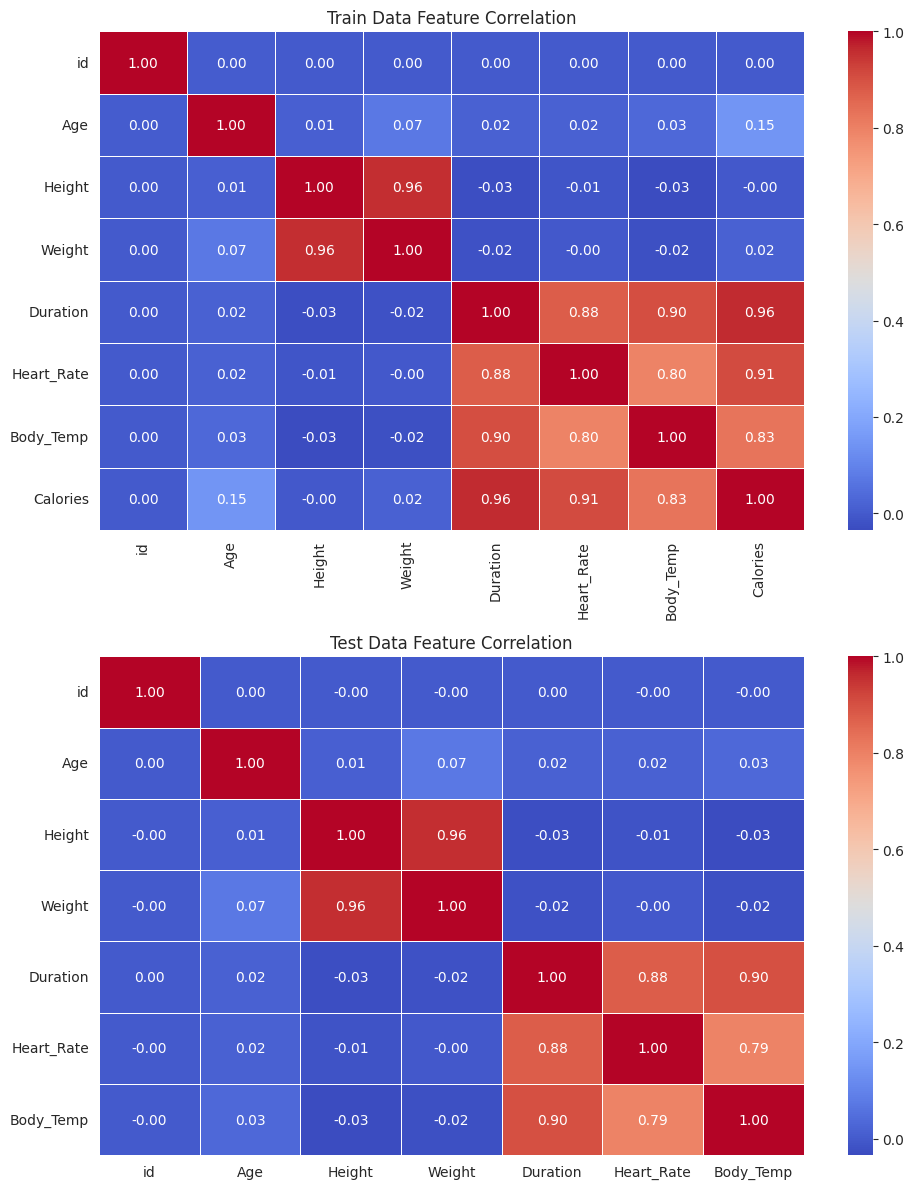

In [14]:
# Create a subplot (1 column, 2 rows)
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

numerical_variables_tmp = ['id', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

# Correlation matrix of df_train
# (if necessary, extract only highly correlated variables.ex：mask=(corr < 0.8)))
sns.heatmap(df_train[numerical_variables].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[0])
axes[0].set_title('Train Data Feature Correlation')

# # Correlation matrix of df_test
# (if necessary, extract only highly correlated variables.ex：mask=(corr < 0.8)))
sns.heatmap(df_test[numerical_variables_tmp].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1])
axes[1].set_title('Test Data Feature Correlation')

# Layout adjustment
plt.tight_layout()
plt.show()

Pairplot of Train Data


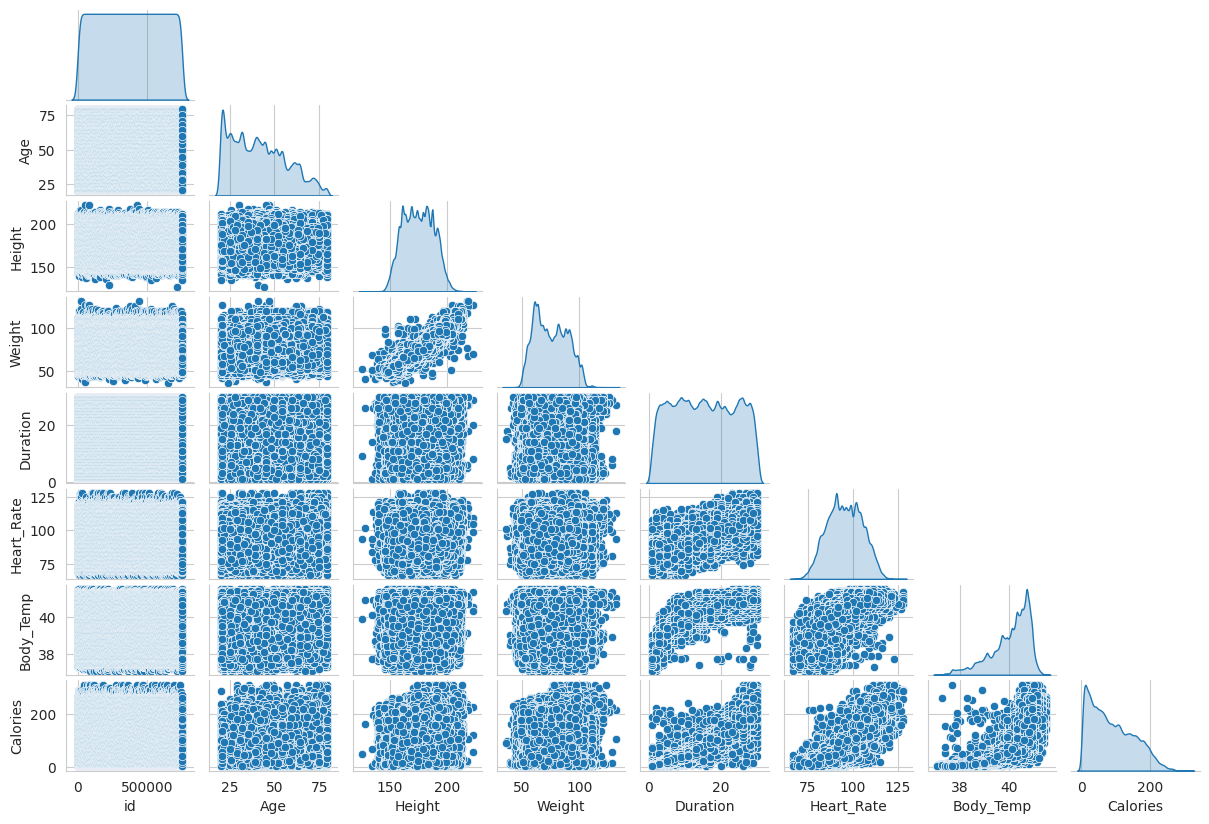

------------------------------------------------------------------------------------------------------
Pairplot of Test Data


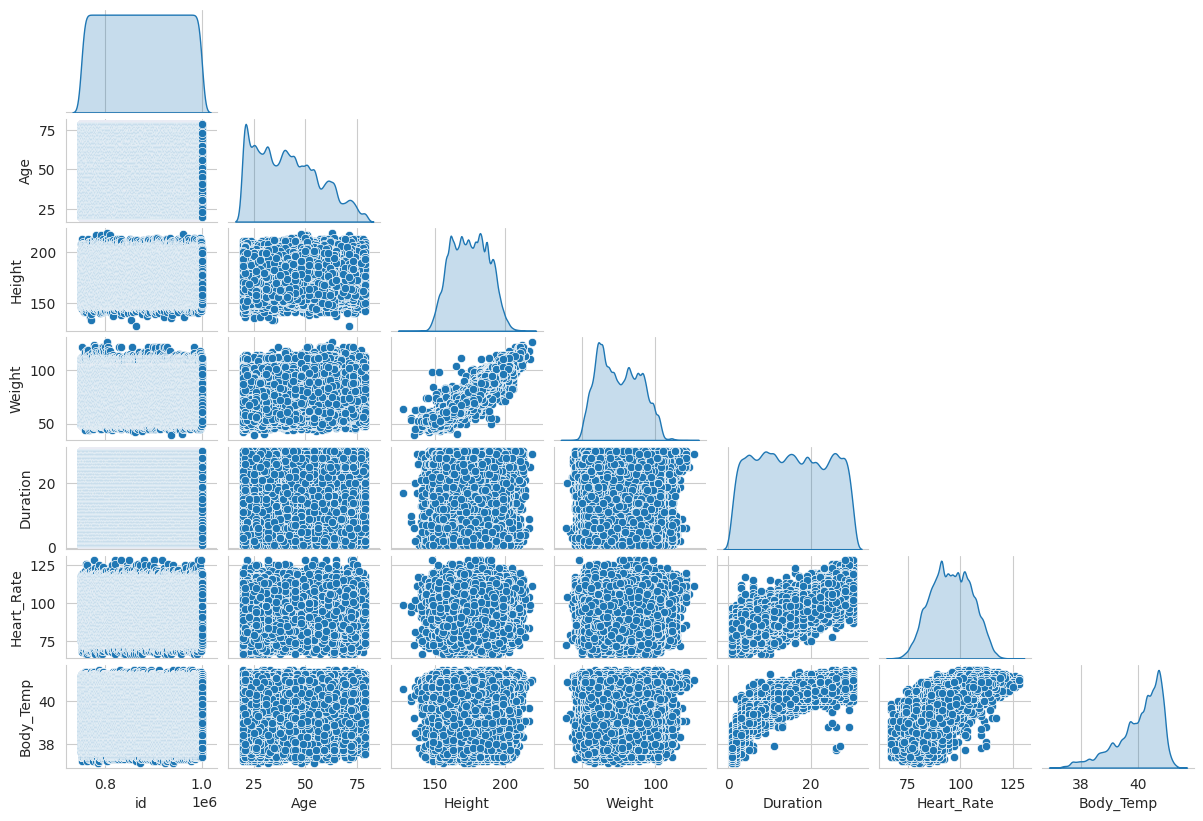

In [15]:
# Making Pairplot
print('Pairplot of Train Data')
grid_train = sns.pairplot(df_train[numerical_variables], corner = True, diag_kind = "kde")
grid_train.fig.set_size_inches(12, 8)
plt.show()

print('------------------------------------------------------------------------------------------------------')

print('Pairplot of Test Data')
grid_test = sns.pairplot(df_test[numerical_variables_tmp], corner = True, diag_kind = "kde")
grid_test.fig.set_size_inches(12, 8)
plt.show()

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>Relationship Between target variable and other variables</b></div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>
  </div>

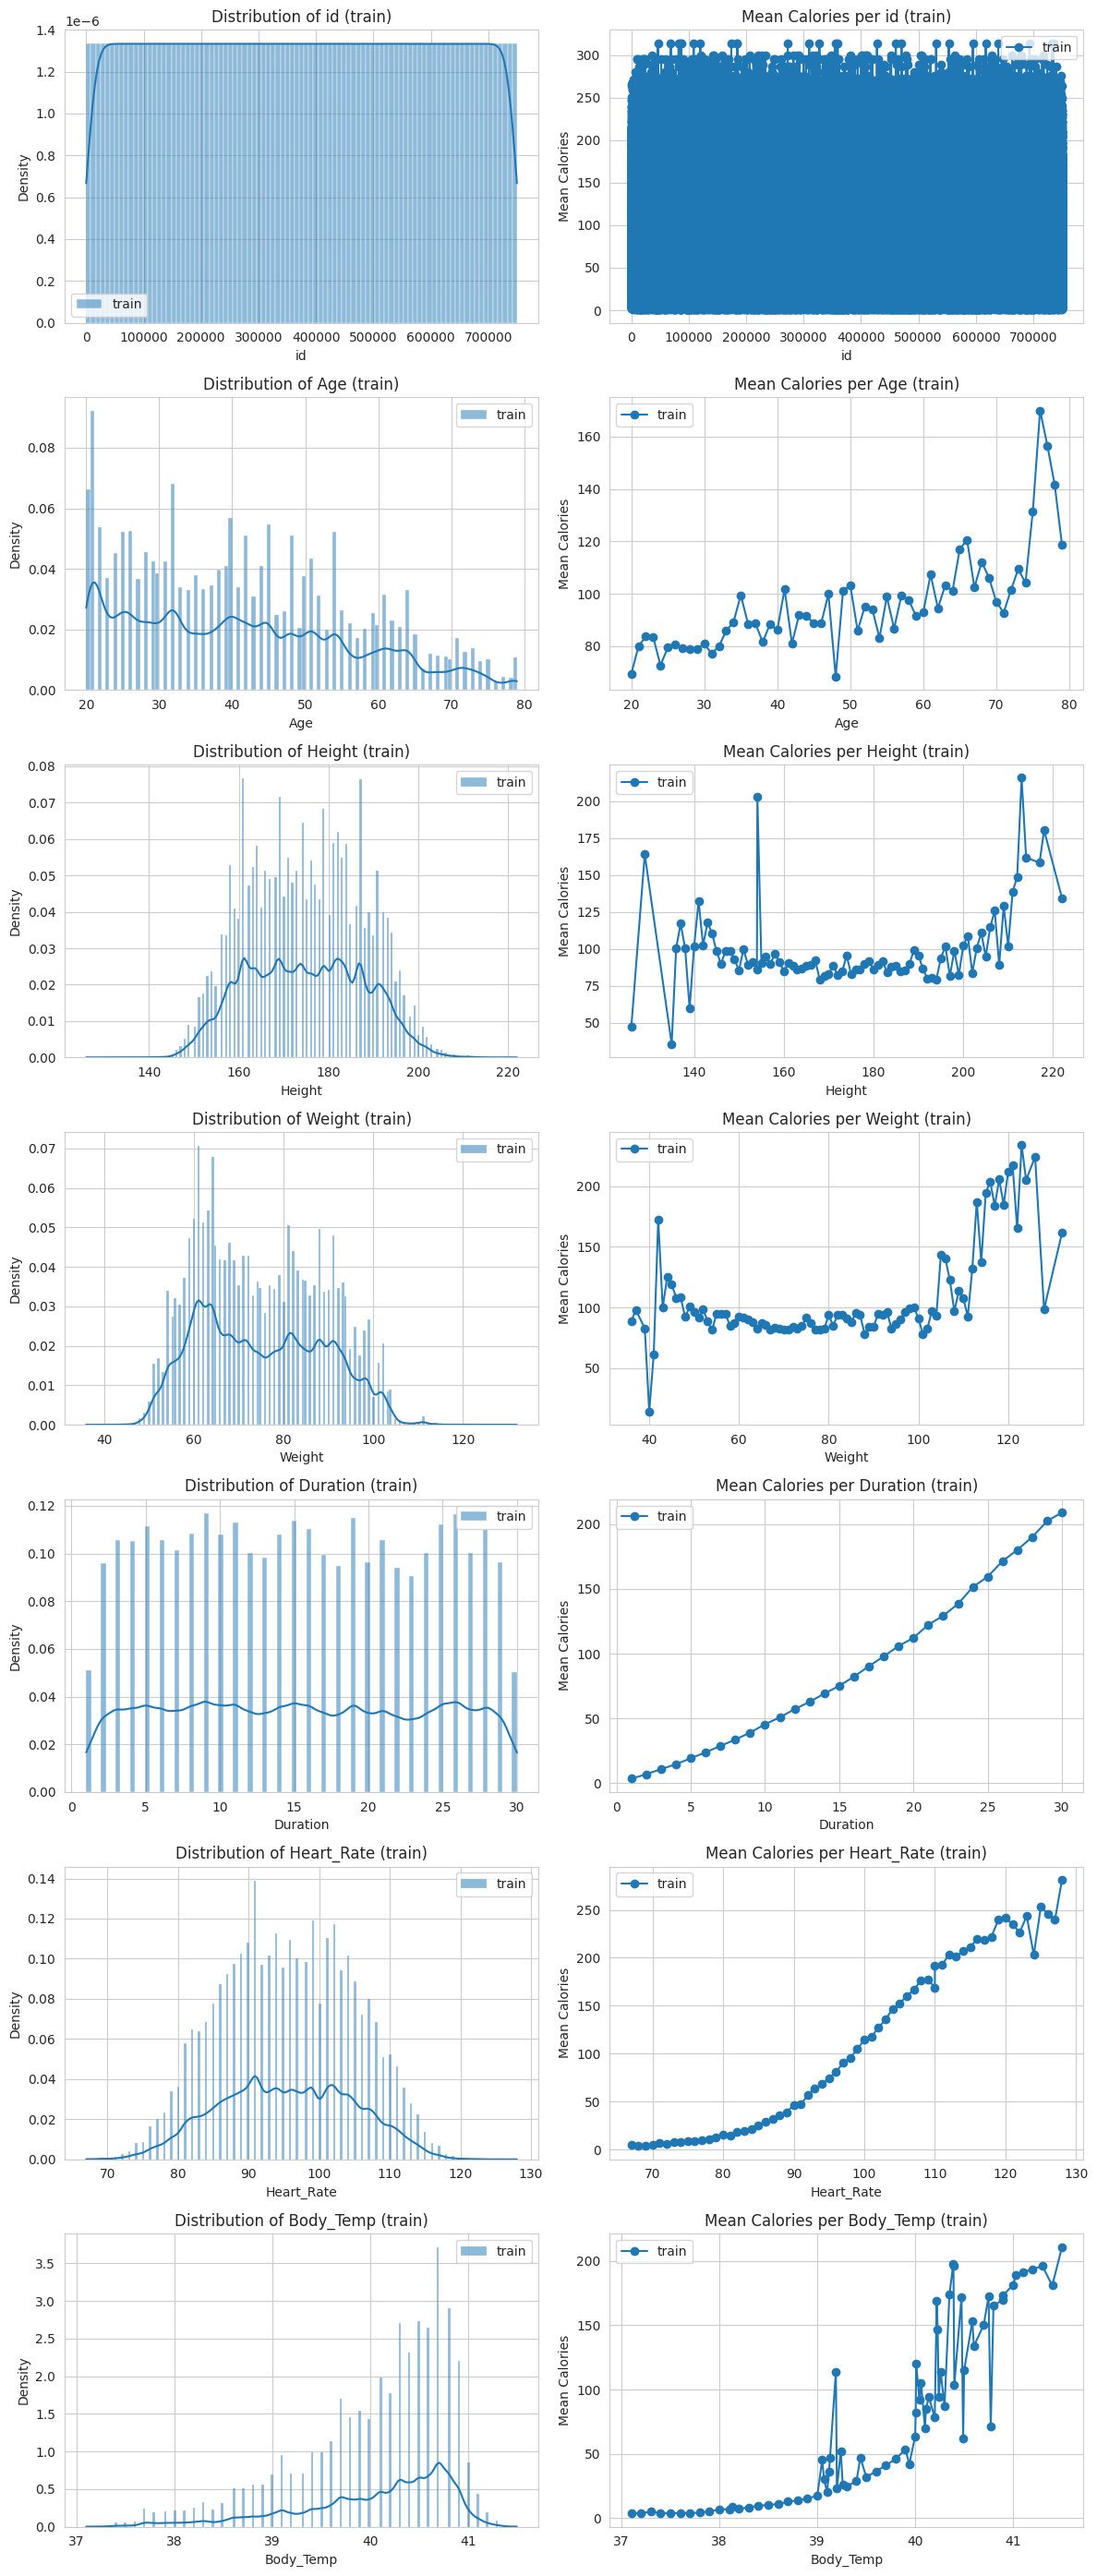

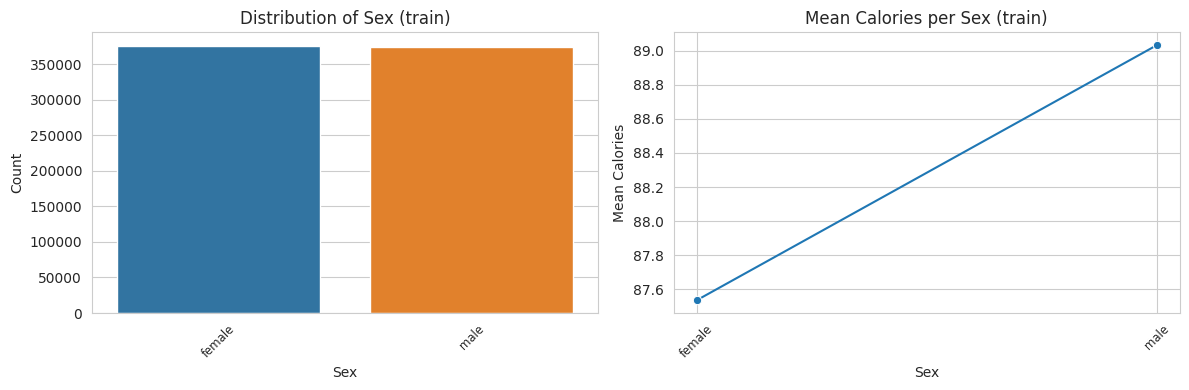

In [16]:
target_col = 'Calories'  #  object variable

# Get numeric and categorical columns
numeric_cols = df_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Exclude the response variable from the numeric column
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# Visualization settings
num_numeric = len(numeric_cols)
num_categorical = len(categorical_cols)

# Visualization of Numeric Variables 
if num_numeric > 0:
    fig_numeric, axes_numeric = plt.subplots(num_numeric, 2, figsize=(12, 4 * num_numeric))
    if num_numeric == 1:
        axes_numeric = axes_numeric.reshape(1, -1) # Treat even a single array as a 2D array
    for i, col in enumerate(numeric_cols):
        
        # Histograms and kernel density estimation
        sns.histplot(df_train[col], stat='density', kde=True, ax=axes_numeric[i, 0], label='train')
        axes_numeric[i, 0].set_title(f'Distribution of {col} (train)')
        axes_numeric[i, 0].set_xlabel(col)
        axes_numeric[i, 0].set_ylabel('Density')
        axes_numeric[i, 0].legend()

        # Line graph of univariate and dependent variable
        df_grouped_numeric = df_train.groupby(col)[target_col].mean().sort_index()
        axes_numeric[i, 1].plot(df_grouped_numeric.index, df_grouped_numeric.values, marker='o', linestyle='-', label='train')
        axes_numeric[i, 1].set_title(f'Mean {target_col} per {col} (train)')
        axes_numeric[i, 1].set_xlabel(col)
        axes_numeric[i, 1].set_ylabel(f'Mean {target_col}')
        axes_numeric[i, 1].grid(True)
        axes_numeric[i, 1].legend()
    plt.tight_layout()
    plt.show()

# Visualization of categorical variables
if num_categorical > 0:
    fig_categorical, axes_categorical = plt.subplots(num_categorical, 2, figsize=(12, 4 * num_categorical))
    if num_categorical == 1:
        axes_categorical = axes_categorical.reshape(1, -1) # Treat even a single array as a 2D array
    for i, col in enumerate(categorical_cols):
        
        # Frequency of categories
        sns.countplot(data=df_train, x=col, ax=axes_categorical[i, 0], order=df_train[col].value_counts().index)
        axes_categorical[i, 0].set_title(f'Distribution of {col} (train)')
        axes_categorical[i, 0].set_xlabel(col)
        axes_categorical[i, 0].set_ylabel('Count')
        axes_categorical[i, 0].tick_params(axis='x', rotation=45)
        axes_categorical[i, 0].tick_params(axis='x', labelsize='small')

        # Relationship between categories and objective variables (Line Plot)
        df_grouped_categorical = df_train.groupby(col)[target_col].mean().sort_index() # sort_index() を追加
        sns.lineplot(x=df_grouped_categorical.index, y=df_grouped_categorical.values, marker='o', linestyle='-', ax=axes_categorical[i, 1])
        axes_categorical[i, 1].set_title(f'Mean {target_col} per {col} (train)')
        axes_categorical[i, 1].set_xlabel(col)
        axes_categorical[i, 1].set_ylabel(f'Mean {target_col}')
        axes_categorical[i, 1].grid(True)
        axes_categorical[i, 1].tick_params(axis='x', rotation=45)
        axes_categorical[i, 1].tick_params(axis='x', labelsize='small')

    plt.tight_layout()
    plt.show()

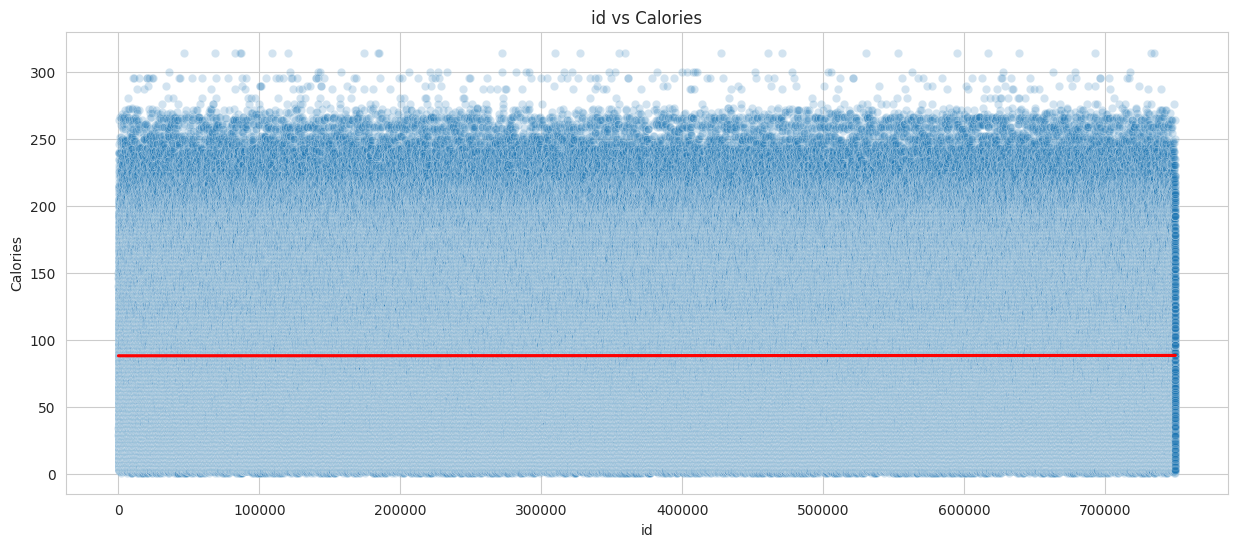

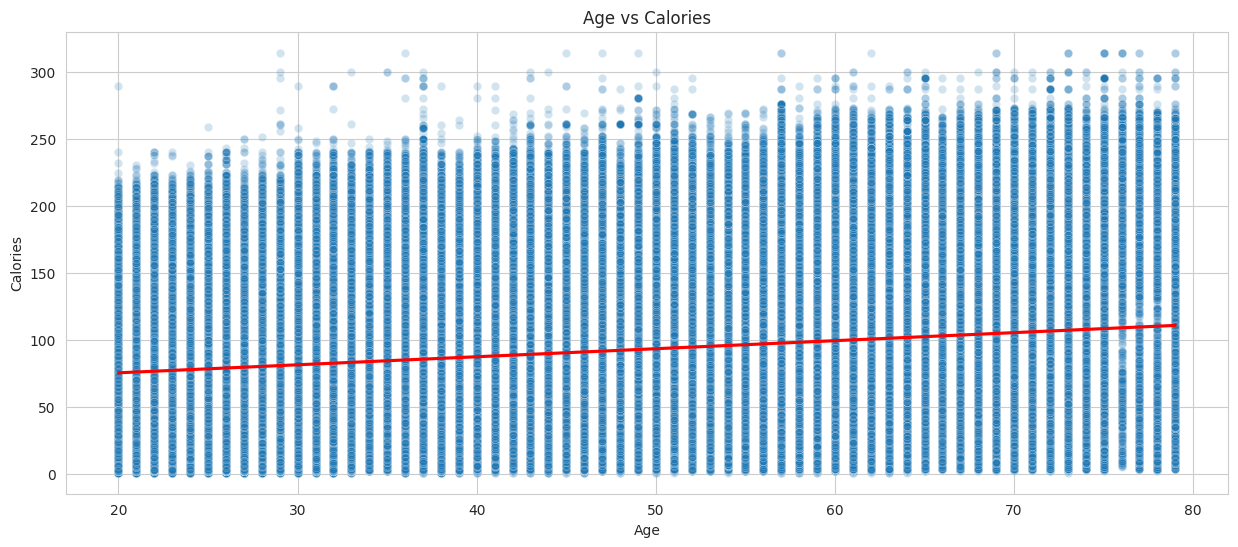

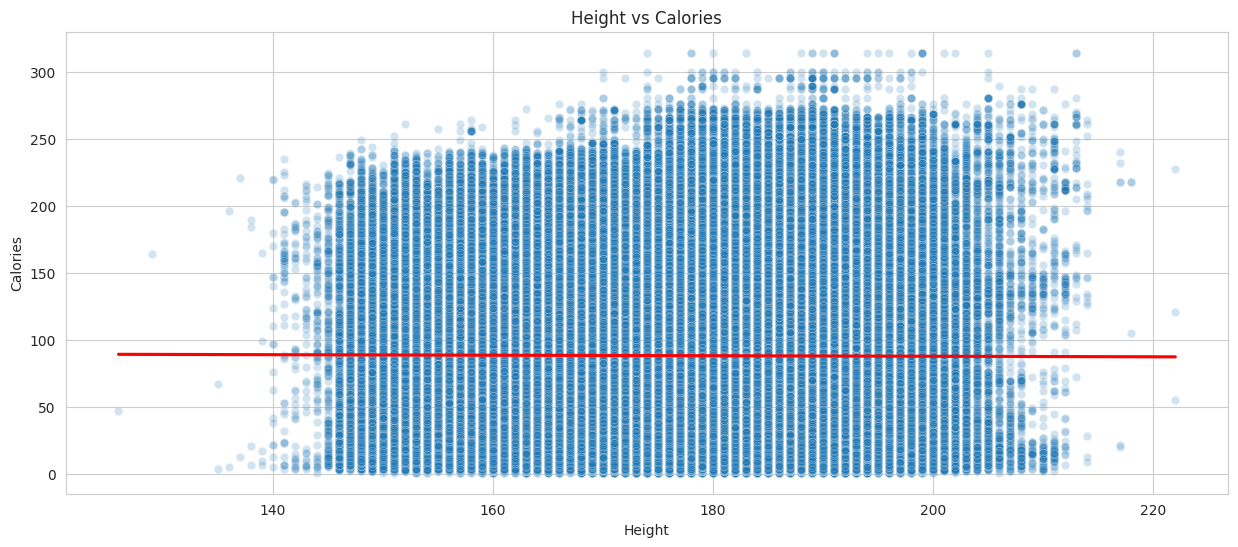

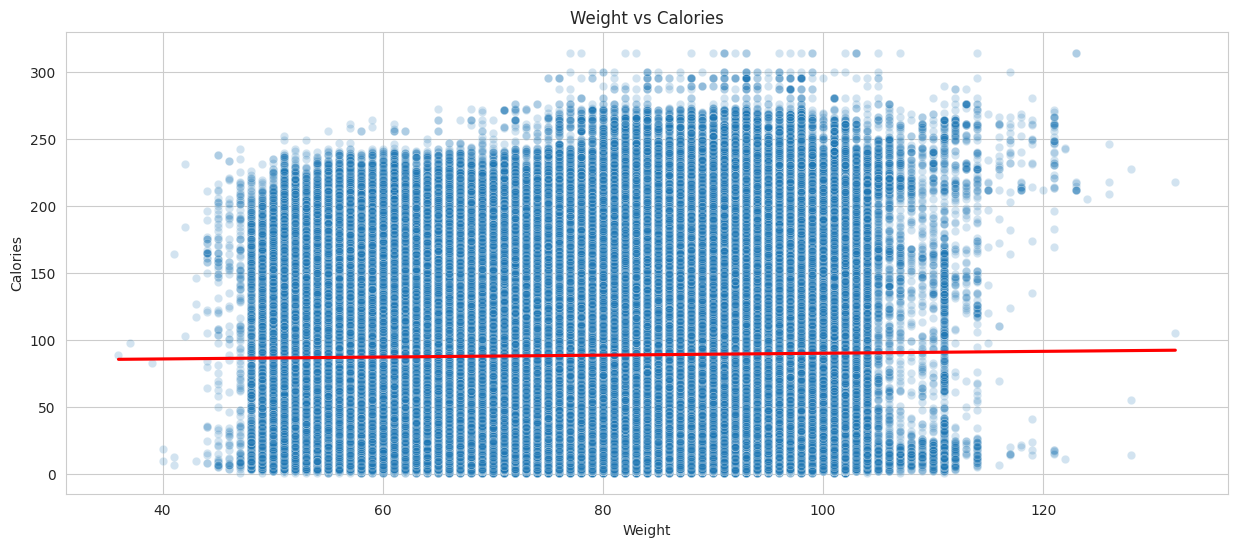

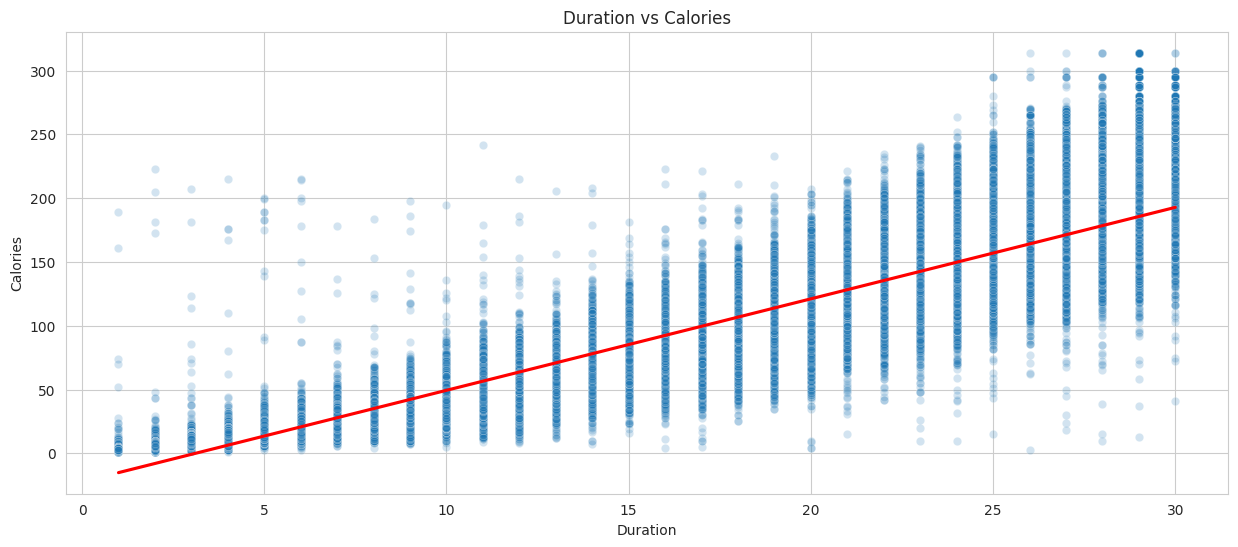

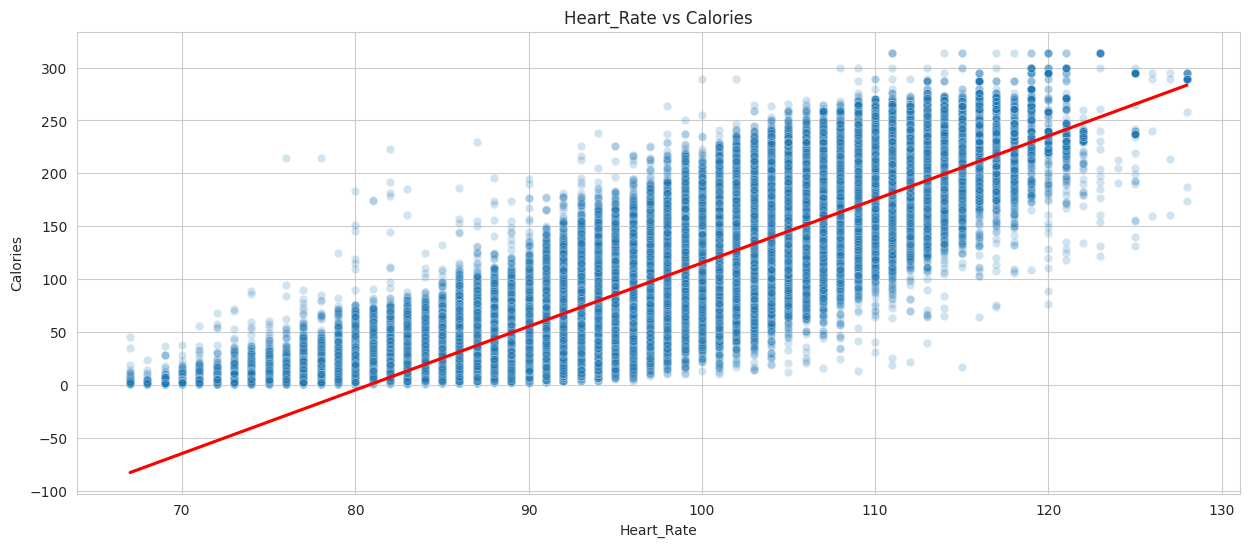

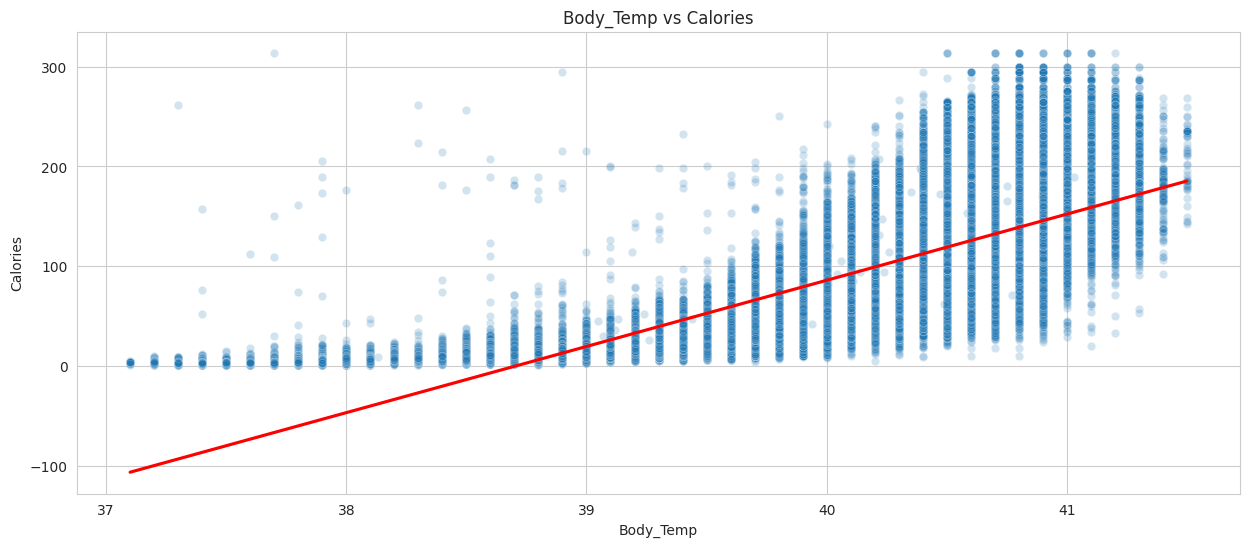

In [17]:
for col in numerical_variables_tmp:
    plt.figure(figsize = (15,6))
    sns.scatterplot(x = df_train[col], y = df_train["Calories"], alpha = 0.2)
    sns.regplot(x = df_train[col], y = df_train["Calories"], scatter = False, color = "red")
    plt.title(f"{col} vs Calories")
    plt.show()

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>VIF <Multicolinearity Check (Variance Inflation Factor)</div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>
  </div>

In [18]:
def calculate_vif(df: pd.DataFrame, numerical_cols: list):
    """
    Calculates and displays the VIF (Variance Inflation Factor) for a specified numeric column in a data frame.

    Args:
        df (pd.DataFrame): The dataframe over which to compute the VIF.
        numerical_cols (list): A list of the names of the numeric columns you want to calculate the VIF for.
                               Do not include the target variable in this list.
    Returns:
        pd.DataFrame: A data frame containing each feature and its VIF value.
    """
    # Create a data frame with only selected numeric columns
    X = df[numerical_cols]
    X_vif = add_constant(X)

    # Initialize a data frame to store the VIFs.
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

    # Display the VIF excluding the constant term (const)
    vif_data = vif_data[vif_data['feature'] != 'const'].sort_values("VIF", ascending=False).style.background_gradient(cmap="viridis")

    return vif_data

In [19]:
calculate_vif(df_train, numerical_variables_tmp)

,feature,VIF
4,Weight,12.766915
3,Height,12.702173
5,Duration,8.510598
7,Body_Temp,5.434871
6,Heart_Rate,4.285832
2,Age,1.050877
1,id,1.000010


In [20]:
calculate_vif(df_test, numerical_variables_tmp)

,feature,VIF
4,Weight,12.723028
3,Height,12.657364
5,Duration,8.502424
7,Body_Temp,5.409066
6,Heart_Rate,4.282299
2,Age,1.050589
1,id,1.000014


# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>Principal Component Analysis</div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>
  </div>

In [21]:
def plot_pca_with_target_quintiles(df: pd.DataFrame, numerical_cols: list, target_col: str, n_components: int = 2):
    """
    Runs PCA on specified numeric columns in a data frame and
    visualizes the results in a scatter plot colored based on the quantiles of the response variable.
    
    Args:
        df (pd.DataFrame): The data frame to be subjected to PCA and visualization.
        numerical_cols (list): A list of names of numeric columns on which you want to run PCA.
        target_col (str): The column name of the objective variable that is the basis for color coding.
        n_components (int): The number of principal components to extract in PCA (default is 2).
    """
    # 1. Create a data frame with only the selected numeric columns and standardize them
    df_pca_target = df[numerical_cols + [target_col]].dropna()

    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_pca_target[numerical_cols])

    # 2. Running PCA
    pca = PCA(n_components=n_components, random_state=42)
    pca_result = pca.fit_transform(scaled_data)

    # 3. Calculating quantiles of the response variable
    target_quintiles = pd.qcut(df_pca_target[target_col], 5, labels=False, duplicates='drop')
    
    # 4. Drawing a scatter plot
    plt.figure(figsize=(10, 5))
    sns.scatterplot(x=pca_result[:, 0],
                    y=pca_result[:, 1],
                    hue=target_quintiles,
                    palette="viridis",
                    alpha=0.3,
                    s=10)

    plt.title(f"PCA – coloured by {target_col} quintile")
    
    # Adjust the legend position
    plt.legend(title="Quintile", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

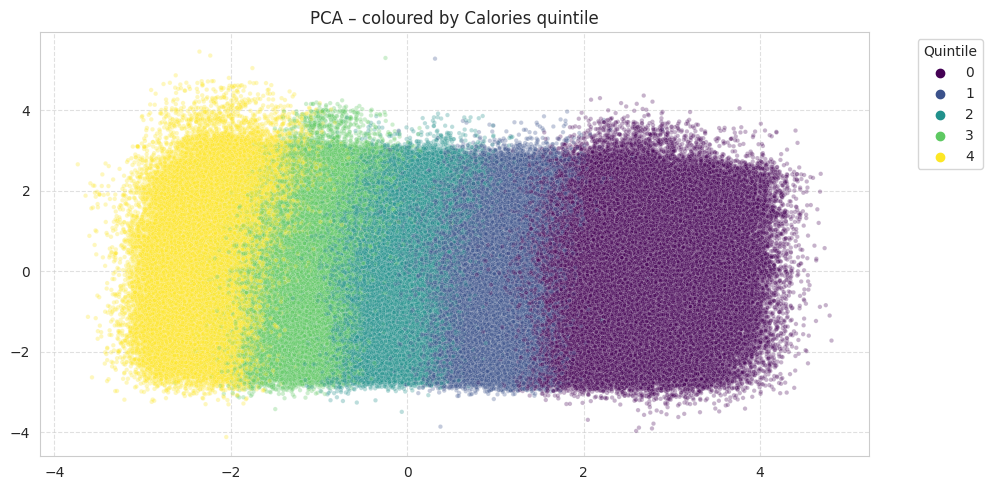

In [22]:
# df_train
plot_pca_with_target_quintiles(df_train, numerical_variables_tmp, "Calories", 5)

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>Train-test Comparability</div>

<div style="background-color: #7851A9; border-left: 8px solid #C9A0DC; padding: 20px; border-radius: 8px; font-size: 14px; color: #FFFFFF;">
  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Findings</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>

  <h5 style="font-size: 16px; margin-bottom: 10px; background-color: #4B0082; padding: 8px; border-radius: 4px; color: #FFFFFF;">
    <strong>Insights</strong> 
  </h5>
  <ul>
    <li>1:sentences</li> 
    <li>2:sentences</li> 
    <li>3:sentences</li> 
  </ul>
  </div>

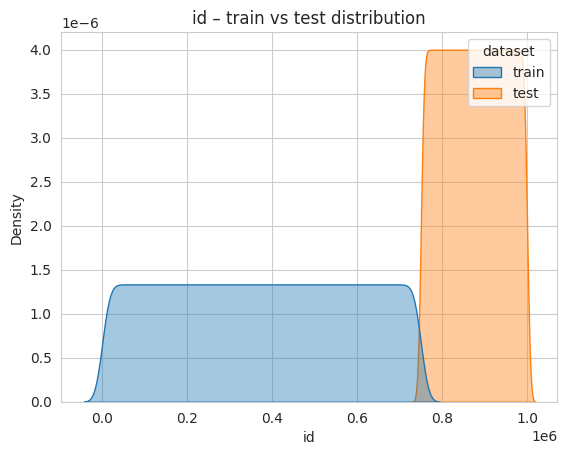

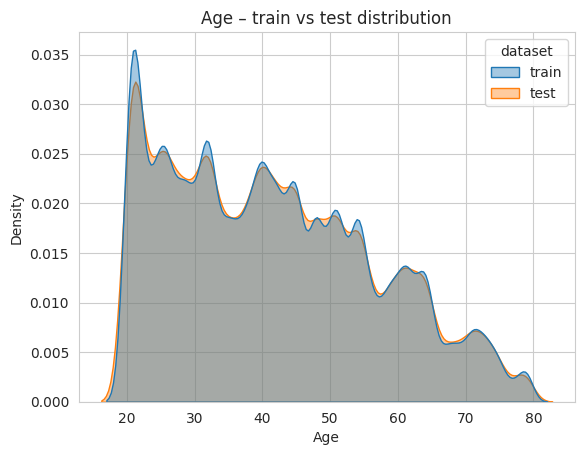

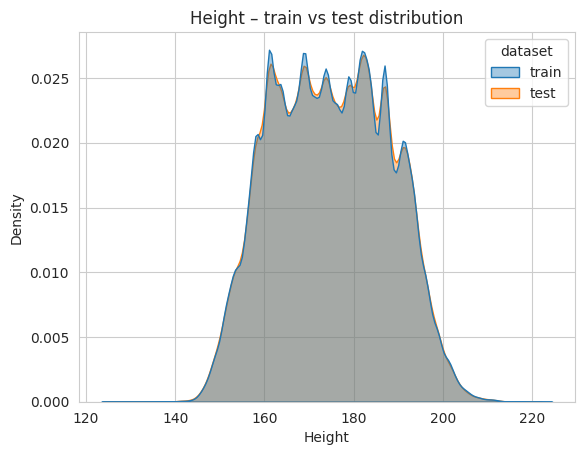

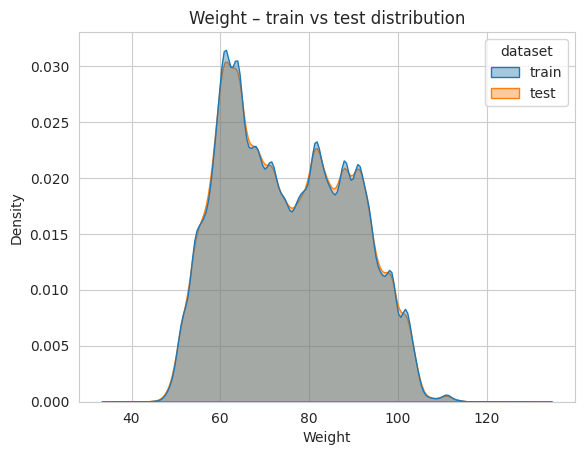

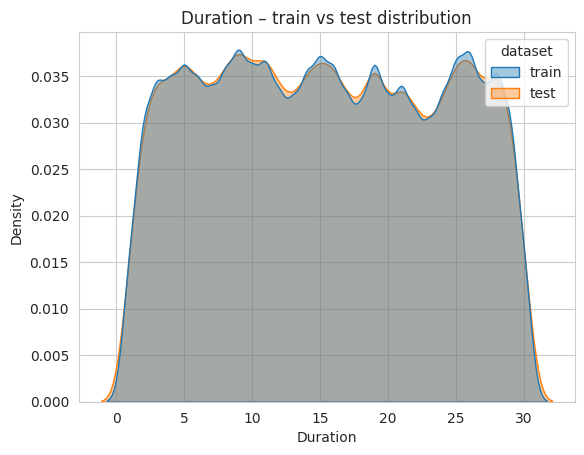

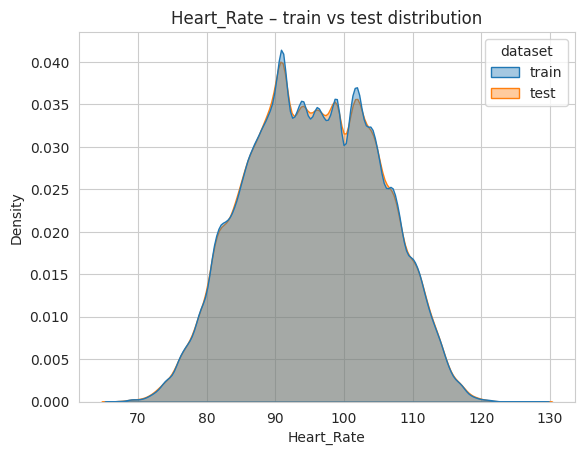

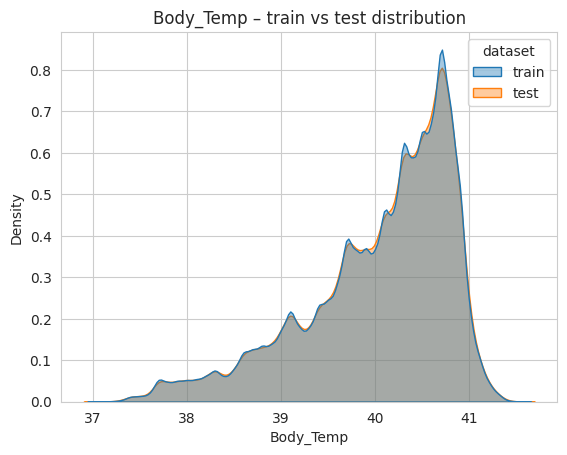

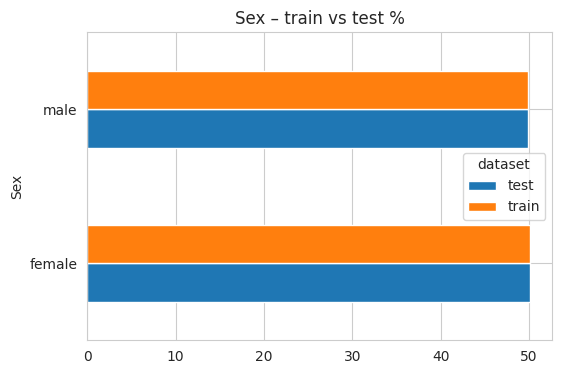

In [23]:
compare_cols = numerical_variables_tmp + ["Sex"]
train_tag = df_train.assign(dataset = "train")[compare_cols + ["dataset"]]
test_tag  = df_test.assign(dataset = "test")[compare_cols + ["dataset"]]
combo = pd.concat([train_tag, test_tag], axis = 0)

for col in compare_cols:
    if col is "Sex":
        ct = pd.crosstab(combo[col], combo["dataset"], normalize = "columns") * 100
        ct.plot.barh(figsize = (6, 4), stacked=False, title = f"{col} – train vs test %")
        plt.show()
    else:
        sns.kdeplot(data = combo, x = col, hue = "dataset", fill = True, common_norm = False, alpha = 0.4)
        plt.title(f"{col} – train vs test distribution"); plt.show()

# <div style="background-color: #7851A9; padding: 12px; font-size: 18px; color: #FFFFFF; border-left: 8px solid #C9A0DC"><b>Check Libiraries Version</b></div>

In [24]:
!pip install watermark

In [25]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,aeppl,xarray

Last updated: Wed May 21 2025

Python implementation: CPython
Python version       : 3.11.11
IPython version      : 7.34.0

pytensor: 2.27.1
aeppl   : not installed
xarray  : 2025.1.2

sklearn    : 1.2.2
missingno  : 0.5.2
matplotlib : 3.7.5
pandas     : 2.2.3
seaborn    : 0.12.2
numpy      : 1.26.4
statsmodels: 0.14.4

Watermark: 2.5.0

